In [11]:
import pandas as pd
import numpy as np

# File paths
APT_PATH = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/Section 2 -Housing Market Heterogeneity/cleaned_data.csv"
MACRO_PATH = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/macro_regimes_final.csv"
SAVE_DIR = "/Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/Section 2 -Housing Market Heterogeneity"

# Load apartment data
apt = pd.read_csv(APT_PATH, parse_dates=["Sale Date"])

# Embed ZIP mapping directly
ZIP_PRIMARY = {
    "Upper West Side": "10024", "Lincoln Square": "10023",
    "Upper East Side": "10028", "Yorkville": "10128",
    "Lenox Hill": "10065", "Chelsea": "10011",
    "Greenwich Village": "10014", "Murray Hill": "10016",
    "Hells Kitchen": "10019", "TriBeCa": "10013",
    "Turtle Bay": "10017", "Sutton Place": "10022",
    "Gramercy Park": "10010", "Midtown Center": "10036",
    "West Village": "10014", "Financial District": "10005",
    "Carnegie Hill": "10128", "East Village": "10009",
    "Lower East Side": "10002", "Kips Bay": "10016",
    "South Harlem": "10026", "Manhattan Valley": "10025",
    "Central Harlem": "10027", "Flatiron": "10010",
    "Battery Park City": "10280", "East Harlem": "10029",
    "NoMad": "10016", "Hudson Heights": "10033",
    "Morningside Heights": "10025", "SoHo": "10012",
    "Hamilton Heights": "10031", "Washington Heights": "10033",
    "Hudson Square": "10013", "South Street Seaport": "10038",
    "NoHo": "10012", "Midtown South": "10001",
    "Two Bridges": "10002", "Inwood": "10034",
    "Hudson Yards": "10001", "Roosevelt Island": "10044",
    "NoLita": "10012", "Chinatown": "10013",
    "Civic Center": "10007", "Fort George": "10040",
    "West Harlem & Manhattanville": "10027", "Little Italy": "10013",
}

# Map sub-neighborhood to ZIP
apt["Sub-Nbhood"] = apt["Sub-Nbhood"].astype(str).str.strip()
apt["ZIP"] = apt["Sub-Nbhood"].map(ZIP_PRIMARY)

# Clean price and date
apt = apt.dropna(subset=["Sale Price", "Sale Date"])

# Floor to month start
apt["month"] = apt["Sale Date"].dt.to_period("M").dt.to_timestamp()

# Bedroom segments
apt["segment"] = apt["Beds"].clip(upper=4).map({
    0: "Studio", 1: "1BR", 2: "2BR", 3: "3BR", 4: "4BR+"
})
apt = apt.dropna(subset=["segment"])

print(f"Transactions: {apt.shape[0]}")
print(f"Date range: {apt['month'].min()} → {apt['month'].max()}")
print(f"Segments: {sorted(apt['segment'].unique())}")
print(f"Neighborhoods: {apt['Sub-Nbhood'].nunique()}")
print(f"ZIP mapped: {apt['ZIP'].notna().sum()} / {len(apt)}")

Transactions: 20937
Date range: 2016-01-01 00:00:00 → 2025-12-01 00:00:00
Segments: ['1BR', '2BR', '3BR', '4BR+', 'Studio']
Neighborhoods: 46
ZIP mapped: 20937 / 20937


In [12]:
MIN_TRANSACTIONS = 5

# Index 1: By bedroom segment (Q2 — apartment type heterogeneity)
segment_index = (
    apt
    .groupby(["month", "segment"])["Sale Price"]
    .agg(["median", "count"])
    .rename(columns={"median": "median_price", "count": "n_transactions"})
    .reset_index()
)
segment_index = segment_index[
    segment_index["n_transactions"] >= MIN_TRANSACTIONS
]
segment_index = segment_index.sort_values(["segment", "month"])
segment_index["appreciation"] = (
    segment_index
    .groupby("segment")["median_price"]
    .pct_change() * 100
)
segment_index = segment_index.dropna(subset=["appreciation"])

print("Segment index:")
for seg in sorted(segment_index["segment"].unique()):
    seg_data = segment_index[segment_index["segment"] == seg]
    print(f"  {seg:<8} {len(seg_data)} months   "
          f"mean: {seg_data['appreciation'].mean():>+6.2f}%   "
          f"std: {seg_data['appreciation'].std():>6.2f}%")

# Index 2: By neighborhood (Q2 — location heterogeneity)
nbhood_index = (
    apt
    .groupby(["month", "Sub-Nbhood"])["Sale Price"]
    .agg(["median", "count"])
    .rename(columns={"median": "median_price", "count": "n_transactions"})
    .reset_index()
)
nbhood_index = nbhood_index[
    nbhood_index["n_transactions"] >= MIN_TRANSACTIONS
]
nbhood_index = nbhood_index.sort_values(["Sub-Nbhood", "month"])
nbhood_index["appreciation"] = (
    nbhood_index
    .groupby("Sub-Nbhood")["median_price"]
    .pct_change() * 100
)
nbhood_index = nbhood_index.dropna(subset=["appreciation"])

nbhood_coverage = (
    nbhood_index
    .groupby("Sub-Nbhood")["month"]
    .count()
    .sort_values(ascending=False)
)
print(f"\nNeighborhoods by coverage:")
print(nbhood_coverage.head(15))
print(f"\nNeighborhoods with 60+ months: {(nbhood_coverage >= 60).sum()}")

Segment index:
  1BR      116 months   mean:  +0.62%   std:  11.32%
  2BR      116 months   mean:  +1.43%   std:  16.68%
  3BR      116 months   mean:  +3.60%   std:  26.24%
  4BR+     115 months   mean:  +6.27%   std:  37.27%
  Studio   116 months   mean:  +1.12%   std:  15.14%

Neighborhoods by coverage:
Sub-Nbhood
Upper East Side      116
Upper West Side      116
Lenox Hill           116
Yorkville            113
Lincoln Square       111
Chelsea              109
Murray Hill           91
Greenwich Village     88
Hells Kitchen         82
Sutton Place          81
TriBeCa               79
Turtle Bay            76
Gramercy Park         69
Midtown Center        61
West Village          61
Name: month, dtype: int64

Neighborhoods with 60+ months: 15


In [13]:

# Raise minimum for 4BR+
segment_index = segment_index[
    ~((segment_index["segment"] == "4BR+") &
      (segment_index["n_transactions"] < 15))
]

# Winsorize all segments at 5th/95th
from scipy.stats.mstats import winsorize

segment_index["appreciation_w"] = (
    segment_index
    .groupby("segment")["appreciation"]
    .transform(lambda x: winsorize(x, limits=[0.05, 0.05]))
)

print("After cleaning:")
for seg in sorted(segment_index["segment"].unique()):
    seg_data = segment_index[segment_index["segment"] == seg]["appreciation_w"]
    print(f"  {seg:<8} mean: {seg_data.mean():>+6.2f}%   "
          f"std: {seg_data.std():>6.2f}%   "
          f"range: [{seg_data.min():>+6.1f}, {seg_data.max():>+6.1f}]")

# ── Continue to Part C ──

After cleaning:
  1BR      mean:  +0.56%   std:  10.56%   range: [ -17.9,  +19.0]
  2BR      mean:  +1.16%   std:  13.38%   range: [ -19.5,  +29.7]
  3BR      mean:  +3.27%   std:  23.72%   range: [ -31.2,  +49.0]
  4BR+     mean:  +9.16%   std:  27.69%   range: [ -41.6,  +62.7]
  Studio   mean:  +0.79%   std:  12.67%   range: [ -19.8,  +23.4]


In [14]:
manhattan_index = (
    apt
    .groupby("month")["Sale Price"]
    .agg(["median", "count"])
    .rename(columns={"median": "median_price", "count": "n_transactions"})
)
manhattan_index = manhattan_index.sort_index()
manhattan_index["appreciation"] = (
    manhattan_index["median_price"].pct_change() * 100
)
manhattan_index = manhattan_index.dropna(subset=["appreciation"])

print(f"\nManhattan aggregate index: {manhattan_index.shape[0]} months")
print(manhattan_index.describe().round(2))


Manhattan aggregate index: 116 months
       median_price  n_transactions  appreciation
count        116.00          116.00        116.00
mean     1205186.89          179.13          1.87
std       211454.21           23.30         19.61
min       784000.00          153.00        -66.18
25%      1100000.00          172.00         -8.70
50%      1195000.00          178.00          2.19
75%      1274875.00          182.00         10.74
max      2912500.00          347.00        134.26


In [15]:
macro = pd.read_csv(MACRO_PATH, parse_dates=["observation_date"])
macro = macro.set_index("observation_date")

merge_cols = [
    "FEDFUNDS", "UNRATE", "PCE_YOY", "MORTGAGE_SPREAD",
    "regime", "regime_name"
]

segment_index = segment_index.merge(
    macro[merge_cols], left_on="month", right_index=True, how="inner"
)

nbhood_index = nbhood_index.merge(
    macro[merge_cols], left_on="month", right_index=True, how="inner"
)

manhattan_index = manhattan_index.merge(
    macro[merge_cols], left_index=True, right_index=True, how="inner"
)

print(f"Segment index:   {segment_index.shape}")
print(f"Nbhood index:    {nbhood_index.shape}")
print(f"Manhattan index: {manhattan_index.shape}")

Segment index:   (490, 12)
Nbhood index:    (1663, 11)
Manhattan index: (115, 9)


/var/folders/kk/0ztqq9nd0kq2b6m409rzjc580000gn/T/ipykernel_23726/1017893432.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box,
/var/folders/kk/0ztqq9nd0kq2b6m409rzjc580000gn/T/ipykernel_23726/1017893432.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box,
/var/folders/kk/0ztqq9nd0kq2b6m409rzjc580000gn/T/ipykernel_23726/1017893432.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box,
/var/folders/kk/0ztqq9nd0kq2b6m409rzjc580000gn/T/ipykernel_23726/1017893432.py:

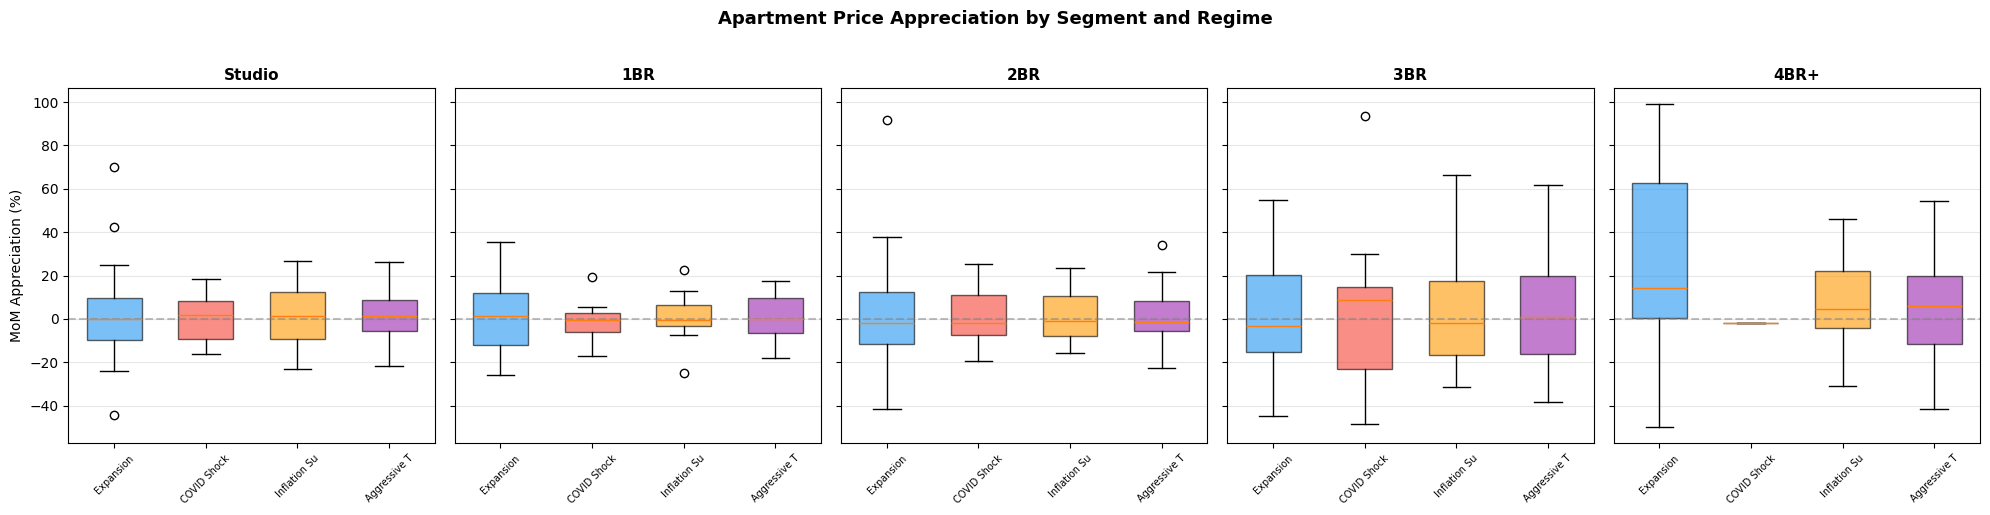

In [16]:
import matplotlib.pyplot as plt

regime_order = [
    "Expansion / Normalization",
    "COVID Shock",
    "Inflation Surge",
    "Aggressive Tightening"
]
regime_colors = {
    "Expansion / Normalization": "#2196F3",
    "COVID Shock":               "#F44336",
    "Inflation Surge":           "#FF9800",
    "Aggressive Tightening":     "#9C27B0"
}

segments = ["Studio", "1BR", "2BR", "3BR", "4BR+"]

fig, axes = plt.subplots(1, len(segments), figsize=(20, 5), sharey=True)

for ax, seg in zip(axes, segments):
    data_for_box = []
    colors_for_box = []
    labels_for_box = []

    for r in regime_order:
        subset = segment_index[
            (segment_index["segment"] == seg) &
            (segment_index["regime_name"] == r)
        ]["appreciation"]
        data_for_box.append(subset.values)
        colors_for_box.append(regime_colors[r])
        labels_for_box.append(r.split("/")[0].strip()[:12])

    bp = ax.boxplot(data_for_box, labels=labels_for_box,
                    patch_artist=True, widths=0.6)
    for patch, color in zip(bp["boxes"], colors_for_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_title(seg, fontsize=11, fontweight="bold")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("MoM Appreciation (%)")
fig.suptitle(
    "Apartment Price Appreciation by Segment and Regime",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/segment_regime_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
segment_index.to_csv(f"{SAVE_DIR}/segment_regime_merged.csv", index=False)
nbhood_index.to_csv(f"{SAVE_DIR}/nbhood_regime_merged.csv", index=False)
manhattan_index.to_csv(f"{SAVE_DIR}/manhattan_regime_merged.csv")

print("Saved:")
print(f"  {SAVE_DIR}/segment_regime_merged.csv   → Q2 (type heterogeneity)")
print(f"  {SAVE_DIR}/nbhood_regime_merged.csv    → Q2 (location heterogeneity)")
print(f"  {SAVE_DIR}/manhattan_regime_merged.csv  → Q3 (Granger causality)")

Saved:
  /Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/Section 2 -Housing Market Heterogeneity/segment_regime_merged.csv   → Q2 (type heterogeneity)
  /Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/Section 2 -Housing Market Heterogeneity/nbhood_regime_merged.csv    → Q2 (location heterogeneity)
  /Users/alicexu/Documents/MSAA/2026_Spring/5205/AML2_Final_Project/Dataset/Section 2 -Housing Market Heterogeneity/manhattan_regime_merged.csv  → Q3 (Granger causality)


In [18]:
# Identify the extreme outlier months
for seg in ["2BR", "4BR+"]:
    extreme = segment_index[
        (segment_index["segment"] == seg) &
        (segment_index["appreciation"].abs() > 50)
    ][["month", "segment", "appreciation", "n_transactions", "regime_name"]]

    if len(extreme) > 0:
        print(f"\n{seg} — months with >50% MoM swing:")
        print(extreme.to_string(index=False))


2BR — months with >50% MoM swing:
     month segment  appreciation  n_transactions               regime_name
2019-06-01     2BR     91.566886              59 Expansion / Normalization

4BR+ — months with >50% MoM swing:
     month segment  appreciation  n_transactions               regime_name
2017-11-01    4BR+     62.668539              22 Expansion / Normalization
2019-06-01    4BR+     98.878089              30 Expansion / Normalization
2024-02-01    4BR+     54.304636              19     Aggressive Tightening


In [19]:
# Winsorize extreme values (optional robustness)
from scipy.stats.mstats import winsorize

segment_index["appreciation_winsorized"] = (
    segment_index
    .groupby("segment")["appreciation"]
    .transform(lambda x: winsorize(x, limits=[0.05, 0.05]))
)

/var/folders/kk/0ztqq9nd0kq2b6m409rzjc580000gn/T/ipykernel_23726/1643670132.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box,
/var/folders/kk/0ztqq9nd0kq2b6m409rzjc580000gn/T/ipykernel_23726/1643670132.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box,
/var/folders/kk/0ztqq9nd0kq2b6m409rzjc580000gn/T/ipykernel_23726/1643670132.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box,
/var/folders/kk/0ztqq9nd0kq2b6m409rzjc580000gn/T/ipykernel_23726/1643670132.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot()

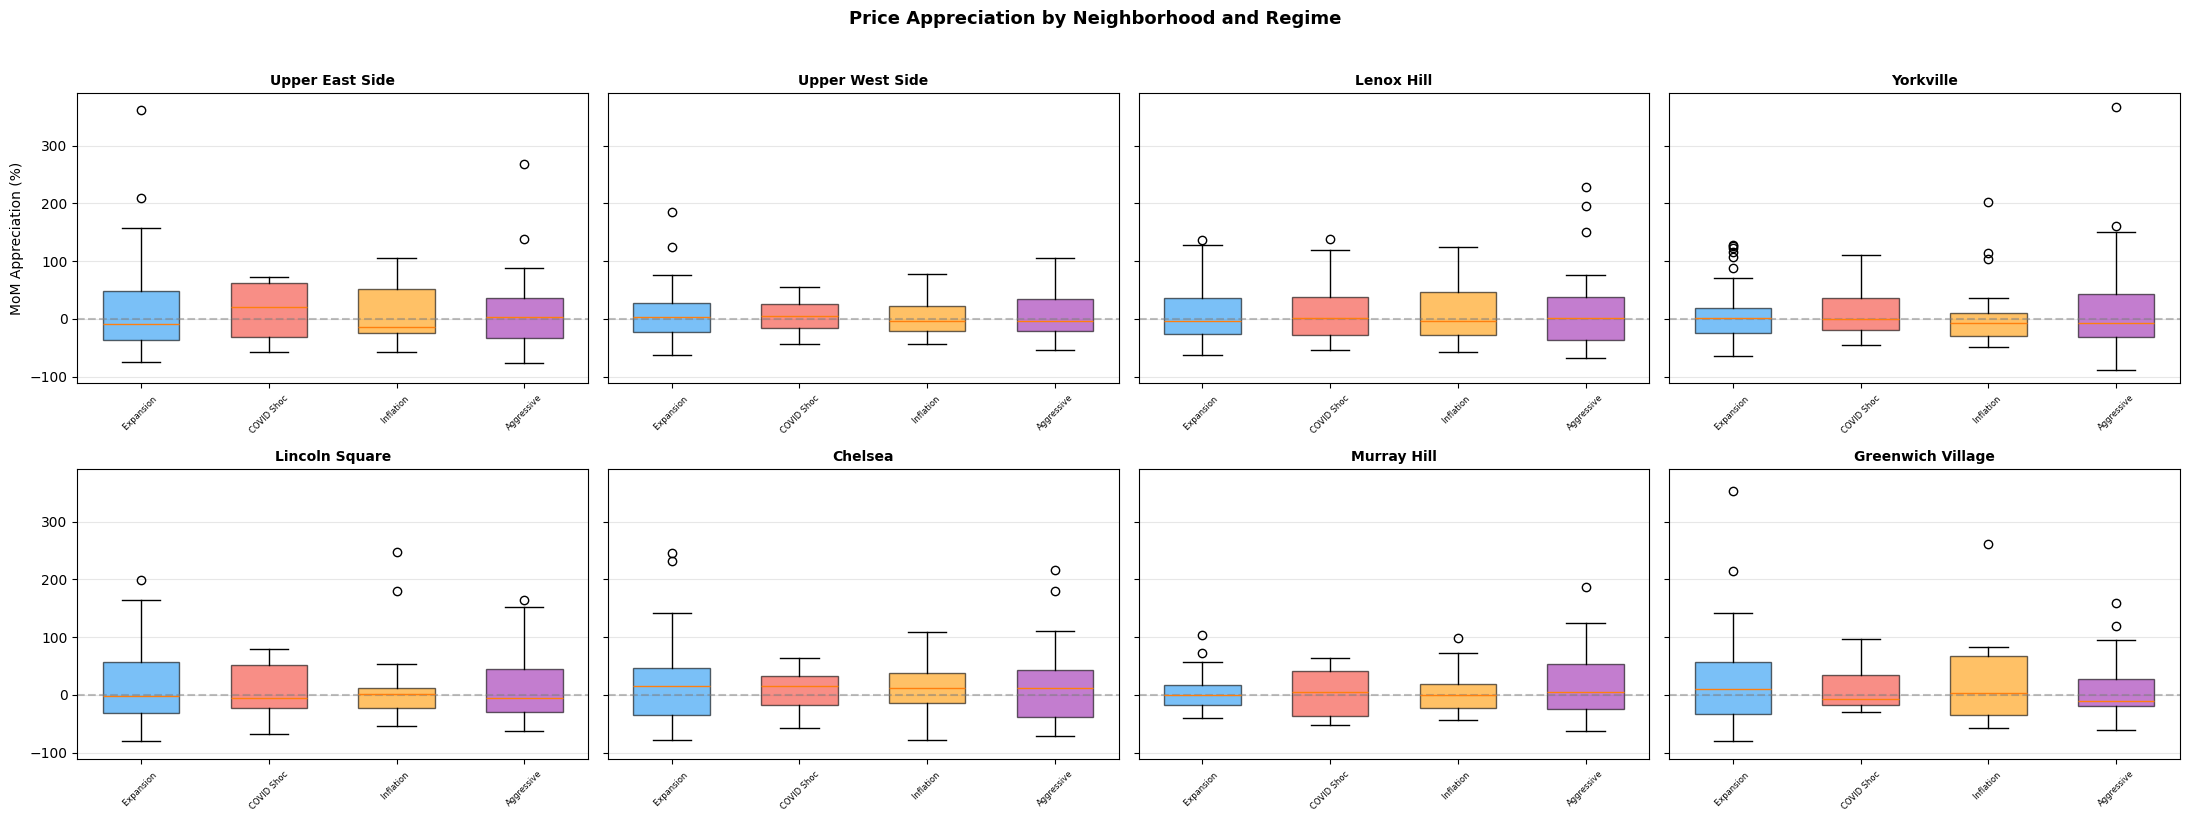

In [20]:
# Top neighborhoods by data coverage
top_nbhoods = nbhood_coverage[nbhood_coverage >= 60].index.tolist()[:8]

fig, axes = plt.subplots(2, 4, figsize=(22, 8), sharey=True)
axes = axes.flatten()

for ax, nbhood in zip(axes, top_nbhoods):
    data_for_box = []
    for r in regime_order:
        subset = nbhood_index[
            (nbhood_index["Sub-Nbhood"] == nbhood) &
            (nbhood_index["regime_name"] == r)
        ]["appreciation"]
        data_for_box.append(subset.values)

    bp = ax.boxplot(data_for_box,
                    labels=[r[:10] for r in regime_order],
                    patch_artist=True, widths=0.6)
    for patch, color in zip(bp["boxes"],
                            ["#2196F3", "#F44336", "#FF9800", "#9C27B0"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_title(nbhood, fontsize=10, fontweight="bold")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.tick_params(axis="x", rotation=45, labelsize=6)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("MoM Appreciation (%)")
fig.suptitle("Price Appreciation by Neighborhood and Regime",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/nbhood_regime_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
from scipy import stats
# Kruskal-Wallis statistical test
print("=" * 70)
print("Kruskal-Wallis: Does appreciation differ across regimes?")
print("=" * 70)

for seg in sorted(segment_index["segment"].unique()):
    groups = [
        segment_index[
            (segment_index["segment"] == seg) &
            (segment_index["regime_name"] == r)
        ]["appreciation_w"].values
        for r in regime_order
    ]
    # Filter out empty groups
    groups = [g for g in groups if len(g) > 0]

    if len(groups) >= 2:
        stat, pval = stats.kruskal(*groups)
        sig = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
        print(f"  {seg:<8} H={stat:>8.3f}   p={pval:.4f}  {sig}")

print("=" * 70)

Kruskal-Wallis: Does appreciation differ across regimes?
  1BR      H=   0.436   p=0.9326  
  2BR      H=   0.088   p=0.9932  
  3BR      H=   0.079   p=0.9942  
  4BR+     H=   0.820   p=0.8446  
  Studio   H=   0.196   p=0.9783  


### None of the segments show statistically significant differences in appreciation across regimes. All p-values are above 0.84. This means the median appreciation rates are not statistically distinguishable across the four regimes for any apartment type.